In [2]:
import os
from pyspark.sql.functions import count, col, when, broadcast, udf, pandas_udf, rand, monotonically_increasing_id
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, PCA, StandardScalerModel, PCAModel
from pyspark.ml.clustering import KMeans, KMeansModel
from sklearn.manifold import TSNE
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType, BooleanType, DoubleType, ArrayType, IntegerType, StructType, StructField, FloatType
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from pyspark.ml.evaluation import ClusteringEvaluator
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import umap
from tqdm import tqdm
import torch
import datamol as dm
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
import os
import sys
import pickle

import functions
import importlib
importlib.reload(functions)
from functions import *


In [40]:
spark.stop()

In [3]:
findspark.init()


In [4]:
spark = SparkSession.builder\
    .appName("Molecule Analysis")\
    .config("spark.executor.memory", "22g")\
    .config("spark.driver.memory", "16g")\
    .config("spark.memory.fraction", "0.7")\
    .config("spark.memory.storageFraction", "0.4")\
    .config("spark.network.timeout", "1200s")\
    .config("spark.executor.heartbeatInterval", "200s")\
    .config("spark.sql.broadcastTimeout", "1500s")\
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()


25/02/09 21:44:08 WARN Utils: Your hostname, user-ThinkPad-E15-Gen-2 resolves to a loopback address: 127.0.1.1; using 192.168.0.108 instead (on interface wlp0s20f3)
25/02/09 21:44:08 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/09 21:44:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
filename = "leash-BELKA/train.parquet"
data = spark.read.parquet(filename)

data.printSchema()

data.show(5)

root
 |-- id: long (nullable = true)
 |-- buildingblock1_smiles: string (nullable = true)
 |-- buildingblock2_smiles: string (nullable = true)
 |-- buildingblock3_smiles: string (nullable = true)
 |-- molecule_smiles: string (nullable = true)
 |-- protein_name: string (nullable = true)
 |-- binds: long (nullable = true)

+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
| id|buildingblock1_smiles|buildingblock2_smiles|buildingblock3_smiles|     molecule_smiles|protein_name|binds|
+---+---------------------+---------------------+---------------------+--------------------+------------+-----+
|  0| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|        BRD4|    0|
|  1| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         HSA|    0|
|  2| C#CC[C@@H](CC(=O)...| C#CCOc1ccc(CN)cc1.Cl| Br.Br.NCC1CCCN1c1...|C#CCOc1ccc(CNc2nc...|         sEH|    0|
|  3|

In [7]:
data = data.filter(col("protein_name") == "sEH")

counts = data.groupBy("binds").count().collect()
counts_dict = {row['binds']: row['count'] for row in counts}

count_binds_1 = counts_dict.get(1, 0)
count_binds_0 = counts_dict.get(0, 0)

total_counts = count_binds_1 + count_binds_0
ratio_binds_0 = count_binds_1 / total_counts
ratio_binds_1 = count_binds_1 / total_counts

binds_1 = int(100000 * ratio_binds_1)
binds_0 = 100000-binds_1

binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

sampled_data = binds_0_sampled.union(binds_1_sampled)

sampled_data.groupBy("binds").count().show()

+-----+-----+
|binds|count|
+-----+-----+
|    0|99264|
|    1|  736|
+-----+-----+



In [14]:
desc_schema = StructType([
    StructField("mol_wt", DoubleType(), True),
    StructField("mol_logp", DoubleType(), True),
    StructField("tpsa", DoubleType(), True),
]
)

@pandas_udf(desc_schema)
def calculate_desc(smiles_series: pd.Series) -> pd.DataFrame:

    mols = smiles_series.apply(Chem.MolFromSmiles)
    
    mw = mols.apply(lambda mol: round(Descriptors.MolWt(mol), 3) if mol else None)
    logp = mols.apply(lambda mol: round(Descriptors.MolLogP(mol), 3) if mol else None)
    tpsa = mols.apply(lambda mol: round(Descriptors.TPSA(mol), 3) if mol else None)


    return pd.DataFrame({'mol_wt': mw, 'mol_logp': logp, 'tpsa': tpsa})
    
sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))

25/02/10 08:28:47 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 6344233 ms exceeds timeout 1200000 ms
25/02/10 08:28:47 WARN SparkContext: Killing executors is not supported by current scheduler.
25/02/10 08:29:02 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:322)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:117)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:116)
	at org.apache.spark.storage

In [9]:
selected_columns = [
    "id",
    col("molecule.mol_wt").alias("molecule_mol_wt"),
    col("molecule.mol_logp").alias("molecule_mol_logp"),
    col("molecule.tpsa").alias("molecule_tpsa"),
    col("block1.mol_wt").alias("block1_mol_wt"),
    col("block1.mol_logp").alias("block1_mol_logp"),
    col("block1.tpsa").alias("block1_tpsa"),
    col("block2.mol_wt").alias("block2_mol_wt"),
    col("block2.mol_logp").alias("block2_mol_logp"),
    col("block2.tpsa").alias("block2_tpsa"),
    col("block3.mol_wt").alias("block3_mol_wt"),
    col("block3.mol_logp").alias("block3_mol_logp"),
    col("block3.tpsa").alias("block3_tpsa"),
    "binds"
]

flattened_data = sampled_data_with_desc.select(*selected_columns)

In [10]:
desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

In [21]:
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(sampled_data_with_features)
scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

In [22]:
scaler_model.write().overwrite().save("./intermediates/scaler_model")

In [9]:
scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
scaled_data = scaler_model.transform(sampled_data_with_features)

In [68]:
pca = PCA(k=8, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca.fit(scaled_data)
reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

In [69]:
pca_model.write().overwrite().save("./intermediates/pca_model")

In [10]:
pca_model = PCAModel.load("./intermediates/pca_model")
reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

In [13]:
kmeans = KMeans(k = 30, seed = 42, maxIter = 10, featuresCol = 'pca_features', predictionCol = 'kmeans_cluster')
k_means_model = kmeans.fit(reduced_data)
kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

In [ ]:
k_means_model.write().overwrite().save("./intermediates/k_means_model")

In [11]:
k_means_model = KMeansModel.load("./intermediates/k_means_model")
kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")
kmeans_clusters.write.save("./intermediates/kmeans_clusters", format="parquet", mode='overwrite')

In [25]:
kmeans_clusters = spark.read.parquet("./intermediates/kmeans_clusters")

In [34]:
all_clustered_data = kmeans_clusters

for i in range(5):
    
    data = data.filter(col("protein_name") == "sEH")

    counts = data.groupBy("binds").count().collect()
    counts_dict = {row['binds']: row['count'] for row in counts}

    count_binds_1 = counts_dict.get(1, 0)
    count_binds_0 = counts_dict.get(0, 0)

    total_counts = count_binds_1 + count_binds_0
    ratio_binds_0 = count_binds_1 / total_counts
    ratio_binds_1 = count_binds_1 / total_counts

    binds_1 = int(100000 * ratio_binds_1)
    binds_0 = 100000-binds_1

    binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
    binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

    sampled_data = binds_0_sampled.union(binds_1_sampled)

    sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))
    flattened_data = sampled_data_with_desc.select(*selected_columns)
    desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

    assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
    sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

    scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
    scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

    pca_model = PCAModel.load("./intermediates/pca_model")
    reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

    k_means_model = KMeansModel.load("./intermediates/k_means_model")
    new_kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

    all_clustered_data = all_clustered_data.union(new_kmeans_clusters)


In [35]:
all_clustered_data.write.save("./intermediates/all_clustered_data", format="parquet", mode='overwrite')

In [36]:
all_clustered_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- kmeans_cluster: integer (nullable = true)



In [37]:
all_clustered_data = spark.read.parquet("./intermediates/all_clustered_data")

In [38]:
binds1 = all_clustered_data.filter(col("binds") == 1)
binds0 = all_clustered_data.filter(col("binds") == 0)

In [39]:
binds_1_counts = binds1.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_1")
binds_0_counts = binds0.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_0")


cluster_counts = binds_1_counts.join(binds_0_counts, "kmeans_cluster", "inner")

In [40]:
fractions_df = cluster_counts.withColumn("fraction", (F.col("count_binds_1") * 3) / F.col("count_binds_0"))

fractions = fractions_df.select("kmeans_cluster", "fraction").rdd.collectAsMap()

In [41]:
binds_0_sampled = binds0.sampleBy("kmeans_cluster", fractions, seed=42)

balanced_data = binds1.unionByName(binds_0_sampled.select(binds1.columns))

In [42]:
balanced_data.write.save("./intermediates/balanced_data", format="parquet", mode='overwrite')

In [43]:
data_subset = data.select("id", "molecule_smiles")

final_data = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
final_data.write.save("./intermediates/final_data.parquet", format="parquet", mode='overwrite')

In [26]:
final_data.cache()
final_data.count() 

18061

In [27]:
final_data.printSchema()

root
 |-- id: long (nullable = true)
 |-- binds: long (nullable = true)
 |-- molecule_smiles: string (nullable = true)



In [44]:
final_data = spark.read.parquet("./intermediates/final_data.parquet")

In [45]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = final_data.toPandas()

balanced_data_with_embeddings['molecule_embedding'] = balanced_data_with_embeddings['molecule_smiles'].apply(smiles_embeddings)

In [46]:
X = balanced_data_with_embeddings['molecule_embedding']
y = balanced_data_with_embeddings['binds']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train.tolist(), y_train)  

y_pred = xgb_model.predict(X_test.tolist())
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [08:27:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.8922, F1: 0.7592


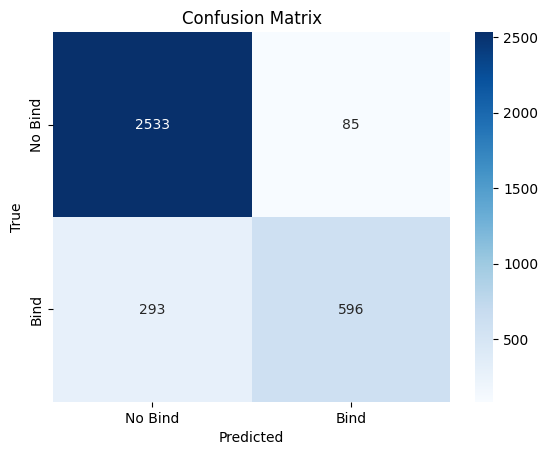

In [47]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

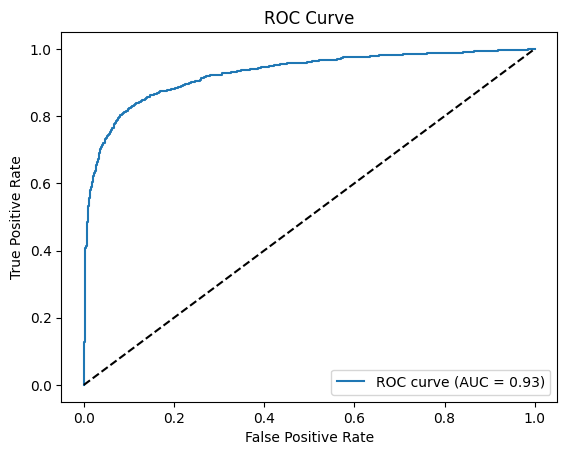

In [48]:
y_pred_proba = xgb_model.predict_proba(X_test.tolist())[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

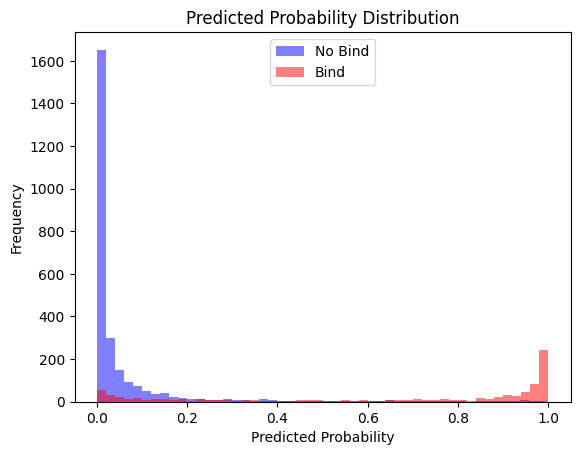

In [49]:
plt.figure()
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5, label='No Bind', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5, label='Bind', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probability Distribution')
plt.legend(loc='upper center')
plt.show()

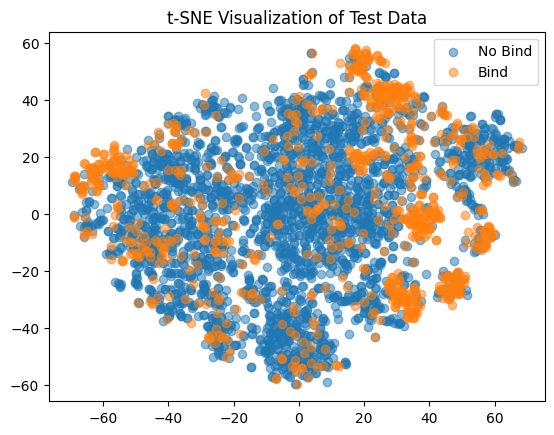

In [50]:
tsne = TSNE(n_components=2, random_state=42)
X_embedded = tsne.fit_transform(np.array(X_test.tolist()))

plt.figure()
plt.scatter(X_embedded[y_test == 0, 0], X_embedded[y_test == 0, 1], label='No Bind', alpha=0.5)
plt.scatter(X_embedded[y_test == 1, 0], X_embedded[y_test == 1, 1], label='Bind', alpha=0.5)
plt.title('t-SNE Visualization of Test Data')
plt.legend()
plt.show()

**all smiles information**

In [ ]:
balanced_data = spark.read.parquet("./intermediates/balanced_data")
data_subset = data.select("id", "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles", "molecule_smiles")

data_full = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
data_full.write.save("./intermediates/data_full", format="parquet", mode='overwrite')

In [67]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = data_full.toPandas()

tqdm.pandas(desc="Generating Embeddings")

balanced_data_with_embeddings['buildingblock1_embedding'] = balanced_data_with_embeddings['buildingblock1_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock2_embedding'] = balanced_data_with_embeddings['buildingblock2_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock3_embedding'] = balanced_data_with_embeddings['buildingblock3_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['molecule_embedding'] = balanced_data_with_embeddings['molecule_smiles'].progress_apply(smiles_embeddings)

Generating Embeddings: 100%|██████████| 17533/17533 [14:05<00:00, 20.73it/s]


In [72]:
X = balanced_data_with_embeddings[['buildingblock1_embedding', 'buildingblock2_embedding', 'buildingblock3_embedding', 'molecule_embedding']]
y = balanced_data_with_embeddings['binds']


X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
X = np.array([np.concatenate(row) for row in X])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)  

y_pred = xgb_model.predict(X_test.tolist())
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

/tmp/ipykernel_193199/2071467526.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [10:17:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9507, F1: 0.9009


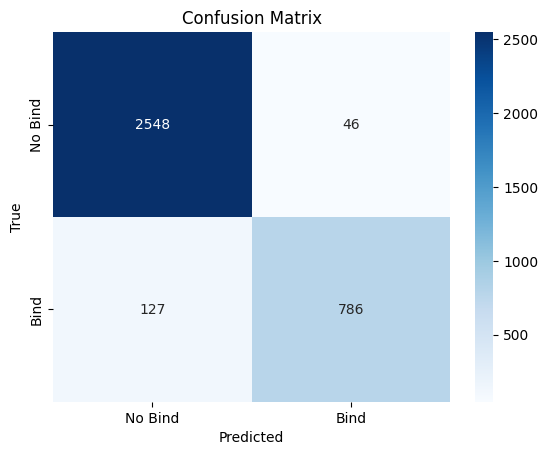

In [73]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Bind', 'Bind'], yticklabels=['No Bind', 'Bind'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

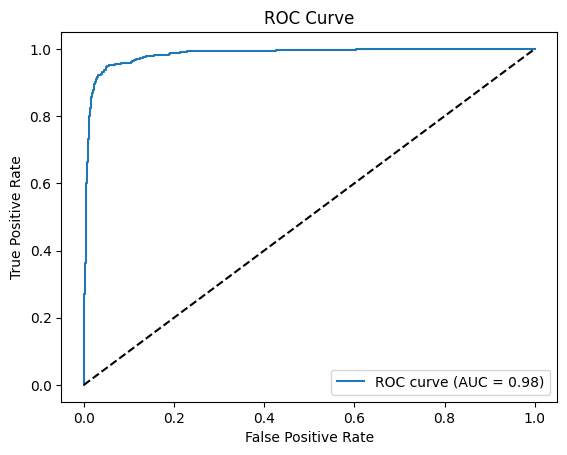

In [75]:
y_pred_proba = xgb_model.predict_proba(X_test.tolist())[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

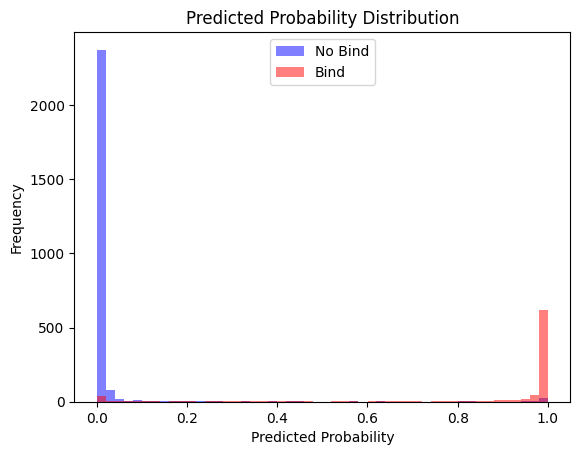

In [76]:
plt.figure()
plt.hist(y_pred_proba[y_test == 0], bins=50, alpha=0.5, label='No Bind', color='blue')
plt.hist(y_pred_proba[y_test == 1], bins=50, alpha=0.5, label='Bind', color='red')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probability Distribution')
plt.legend(loc='upper center')
plt.show()

In [78]:
file_name = "xgb_cls.pkl"

pickle.dump(xgb_model, open(file_name, "wb"))

In [79]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = data_full.toPandas()

tqdm.pandas(desc="Generating Embeddings")

balanced_data_with_embeddings['buildingblock1_embedding'] = balanced_data_with_embeddings['buildingblock1_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock2_embedding'] = balanced_data_with_embeddings['buildingblock2_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock3_embedding'] = balanced_data_with_embeddings['buildingblock3_smiles'].progress_apply(smiles_embeddings)

Generating Embeddings: 100%|██████████| 17533/17533 [08:20<00:00, 35.01it/s]


In [158]:
balanced_data_with_embeddings = balanced_data_with_embeddings.loc[balanced_data_with_embeddings.astype(str).drop_duplicates().index]

In [159]:
X = balanced_data_with_embeddings[['buildingblock1_embedding', 'buildingblock2_embedding', 'buildingblock3_embedding']]
y = balanced_data_with_embeddings['binds']


X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
X = np.array([np.concatenate(row) for row in X])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)  

y_pred = xgb_model.predict(X_test.tolist())
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}, F1: {f1:.4f}')

/tmp/ipykernel_193199/3988748382.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = np.array(X.applymap(lambda x: np.array(x).tolist()).values.tolist())
/home/user/Desktop/Pharm/Medicine/BELKA/venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [18:42:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 0.9549, F1: 0.9091


#Downdsampling using 1 mln data (additional 400 k)

In [11]:


for i in range(4):
    
    data = data.filter(col("protein_name") == "sEH")

    counts = data.groupBy("binds").count().collect()
    counts_dict = {row['binds']: row['count'] for row in counts}

    count_binds_1 = counts_dict.get(1, 0)
    count_binds_0 = counts_dict.get(0, 0)

    total_counts = count_binds_1 + count_binds_0
    ratio_binds_0 = count_binds_1 / total_counts
    ratio_binds_1 = count_binds_1 / total_counts

    binds_1 = int(100000 * ratio_binds_1)
    binds_0 = 100000-binds_1

    binds_1_sampled = data.filter(col("binds") == 1).orderBy(rand()).limit(binds_1)
    binds_0_sampled = data.filter(col("binds") == 0).orderBy(rand()).limit(binds_0)

    sampled_data = binds_0_sampled.union(binds_1_sampled)

    sampled_data_with_desc = sampled_data.withColumn("molecule", calculate_desc(col("molecule_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block1", calculate_desc(col("buildingblock1_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block2", calculate_desc(col("buildingblock2_smiles")))
    sampled_data_with_desc = sampled_data_with_desc.withColumn("block3", calculate_desc(col("buildingblock3_smiles")))
    flattened_data = sampled_data_with_desc.select(*selected_columns)
    desc_columns = [col_name for col_name in flattened_data.columns if col_name != "id" and col_name != "binds"]

    assembler = VectorAssembler(inputCols=desc_columns, outputCol="features")
    sampled_data_with_features = assembler.transform(flattened_data).select("id", "binds", "features")

    scaler_model = StandardScalerModel.load("./intermediates/scaler_model")
    scaled_data = scaler_model.transform(sampled_data_with_features).select("id", "binds", "scaled_features")

    pca_model = PCAModel.load("./intermediates/pca_model")
    reduced_data = pca_model.transform(scaled_data).select("id", "binds", "pca_features")

    k_means_model = KMeansModel.load("./intermediates/k_means_model")
    new_kmeans_clusters = k_means_model.transform(reduced_data).select("id", "binds", "kmeans_cluster")

    all_clustered_data = all_clustered_data.union(new_kmeans_clusters)


In [ ]:
all_clustered_data.write.save("./intermediates/all_clustered_data", format="parquet", mode='overwrite')

In [ ]:
binds1 = all_clustered_data.filter(col("binds") == 1)
binds0 = all_clustered_data.filter(col("binds") == 0)

binds_1_counts = binds1.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_1")
binds_0_counts = binds0.groupBy("kmeans_cluster").count().withColumnRenamed("count", "count_binds_0")


cluster_counts = binds_1_counts.join(binds_0_counts, "kmeans_cluster", "inner")

fractions_df = cluster_counts.withColumn("fraction", (F.col("count_binds_1") * 3) / F.col("count_binds_0"))

fractions = fractions_df.select("kmeans_cluster", "fraction").rdd.collectAsMap()

binds_0_sampled = binds0.sampleBy("kmeans_cluster", fractions, seed=42)

balanced_data = binds1.unionByName(binds_0_sampled.select(binds1.columns))

balanced_data.write.save("./intermediates/balanced_data", format="parquet", mode='overwrite')

balanced_data = spark.read.parquet("./intermediates/balanced_data")
data_subset = data.select("id", "buildingblock1_smiles", "buildingblock2_smiles", "buildingblock3_smiles", "molecule_smiles")

data_full = balanced_data.drop("kmeans_cluster").join(data_subset, on="id", how="left")
data_full.write.save("./intermediates/data_full", format="parquet", mode='overwrite')

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
model = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")


def smiles_embeddings(smiles:str):

    tokens = tokenizer(smiles, padding = True, truncation = True, max_length = 512, return_tensors = 'pt')
    
    with torch.no_grad():
        outputs = model(**tokens)
    
    return outputs.last_hidden_state.mean(dim = 1).squeeze().cpu().numpy().tolist()

balanced_data_with_embeddings = data_full.toPandas()

tqdm.pandas(desc="Generating Embeddings")

balanced_data_with_embeddings['buildingblock1_embedding'] = balanced_data_with_embeddings['buildingblock1_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock2_embedding'] = balanced_data_with_embeddings['buildingblock2_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['buildingblock3_embedding'] = balanced_data_with_embeddings['buildingblock3_smiles'].progress_apply(smiles_embeddings)
balanced_data_with_embeddings['molecule_embedding'] = balanced_data_with_embeddings['molecule_smiles'].progress_apply(smiles_embeddings)

In [ ]:
balanced_data_with_embeddings = balanced_data_with_embeddings.loc[balanced_data_with_embeddings.astype(str).drop_duplicates().index]
balanced_data_with_embeddings.to_parquet('./leash-BELKA/data_with_embeddings.parquet')